# 14-Generative Adversarial Networks (GANs)

In Lesson 13, we used Variational Autoencoders (VAEs) to generate new data. However, VAEs suffer from a fatal visual flaw: **their outputs are inherently blurry.** Because VAEs rely on Mean Squared Error (MSE) to reconstruct images, they mathematically penalize sharp, bold predictions if they are even slightly misaligned. To minimize the MSE penalty, the network "hedges its bets" by producing soft, average pixel values.

If we want to generate hyper-realistic data, we must abandon MSE entirely. Instead of using a static mathematical formula to calculate the loss, what if we used *another Neural Network* to calculate the loss?

In 2014, Ian Goodfellow introduced the **Generative Adversarial Network (GAN)**, fundamentally changing Artificial Intelligence by replacing static calculus with a zero-sum mathematical war between two networks.

Let's set up our PyTorch environment to host the Minimax game.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from skimage import data
from skimage.transform import resize
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch Adversarial Mathematics Environment Ready.")

✅ PyTorch Adversarial Mathematics Environment Ready.


# 1. The Architecture of the Minimax Game

A GAN is not one neural network; it is two completely distinct neural networks locked in an adversarial loop.

### 1. The Generator ($G$)

The Generator's only job is to counterfeit reality. It has absolutely no access to the real dataset. It takes a vector of pure random mathematical noise ($z$) from a Latent Space and passes it through its layers to output a fake image ($G(z)$).

* **Its Goal:** To generate images so flawless that they achieve a 100% success rate at fooling the Discriminator.

### 2. The Discriminator ($D$)

The Discriminator is a standard Binary Classifier. It receives two types of images: Real images from the dataset ($x$), and Fake images from the Generator ($G(z)$). It passes them through its layers and outputs a single probability between $0.0$ and $1.0$.

* **Its Goal:** To perfectly separate reality from fiction. Output $1.0$ for Real, and $0.0$ for Fake.

# 2. The Mathematics of the Value Function

The foundational mathematics of GANs is expressed as a **Minimax Game**. The Discriminator is trying to maximize the function $V$, while the Generator is simultaneously trying to minimize it.

$$\min_G \max_D V(D, G) = \mathbb{E}_{x \sim p_{data}(x)}[\log D(x)] + \mathbb{E}_{z \sim p_z(z)}[\log(1 - D(G(z)))]$$

Let's deconstruct this terrifying equation into engineering logic:

* **Term 1 ($\mathbb{E}[\log D(x)]$):** This is the Discriminator looking at Real data ($x$). It wants $D(x)$ to be exactly $1.0$. Since $\log(1) = 0$, this is the maximum possible value (logarithms of probabilities are always negative).
* **Term 2 ($\mathbb{E}[\log(1 - D(G(z)))]$):** This is the Discriminator looking at Fake data ($G(z)$). The Discriminator wants $D(G(z))$ to be $0.0$, making the term $\log(1 - 0) = 0$.
* **The Generator's Sabotage:** The Generator wants the Discriminator to fail. It wants $D(G(z))$ to equal $1.0$, which mathematically drives Term 2 toward $\log(0) = -\infty$. It is minimizing the function!

# 3. The Non-Saturating Heuristic (The Gradient Fix)

While the Minimax equation is beautifully elegant, it physically fails in code.

At the very beginning of training, the Generator is terrible. It outputs absolute static noise. The Discriminator easily spots the fake and outputs $D(G(z)) \approx 0.0001$.
If we look at the calculus of $\log(1 - x)$ when $x$ is near $0$, the curve is almost perfectly flat. The derivative (gradient) is practically zero. **The Generator cannot learn because its gradient has vanished!**

To fix this, researchers altered the Generator's Loss Function in code.
Instead of telling the Generator to *minimize* $\log(1 - D(G(z)))$, we tell it to **maximize $\log(D(G(z)))$**.
Mathematically, the goal is the same (fool the Discriminator), but the calculus of $\log(x)$ when $x \approx 0$ provides a massive, steep gradient, allowing the Generator to learn rapidly even when it is terrible.

# 4. Architecting a Vanilla GAN in PyTorch

To understand the core adversarial loop, we will architect a Vanilla GAN using Multi-Layer Perceptrons (MLPs) just like the original 2014 paper. We will process our high-resolution cat image down to $64 \times 64$ so our Dense networks can handle the dimensions.

Notice how we use `nn.BCELoss` (Binary Cross Entropy) to mathematically enforce the Minimax game, and exactly how the `.detach()` method is used to protect the gradients.

--- ⚙️ Initializing Minimax Operations ---
--- ⚔️ Executing Adversarial Training Step ---
Discriminator Loss: 0.6870 (Lower is better for D)
Generator Loss:     0.8011 (Lower is better for G)


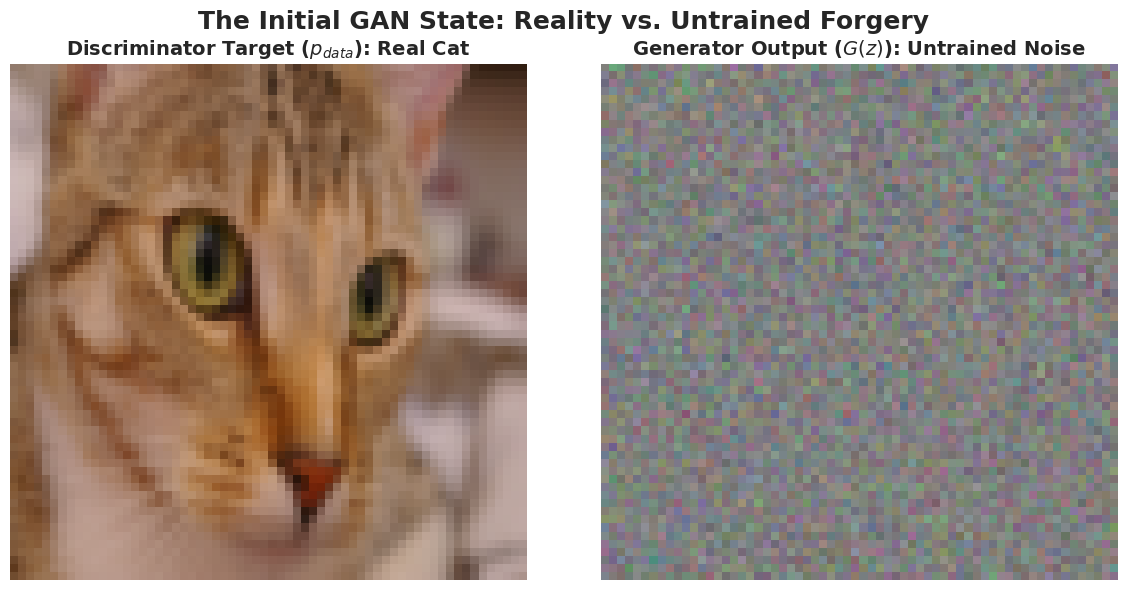

--- 💡 Architectural Insight ---
Right now, the Generator produces complete static noise (Plot 2). The Discriminator easily outputs a probability of ~0.0% that this is real. However, during Phase 2 of our loop, the Generator received a gradient purely based on the mathematical vulnerability of the Discriminator. It just learned exactly how to adjust its 12,288 pixels to push the Discriminator's output fractionally closer to 1.0!


In [2]:
# 1. Fetch and Preprocess the Target Real Data
numpy_cat = data.chelsea()
# Resize to 64x64 for MLP processing
resized_cat = resize(numpy_cat, (64, 64), anti_aliasing=True)

# Deep Learning Normalization for GANs: 
# Generators use Tanh() at the output, which bounds pixels between [-1.0, 1.0].
# Therefore, our Real data MUST ALSO be normalized to [-1.0, 1.0], not [0.0, 1.0]!
normalized_cat = (resized_cat * 2.0) - 1.0
real_image_tensor = torch.tensor(normalized_cat, dtype=torch.float32).permute(2, 0, 1) # [3, 64, 64]

# Flatten the image for the MLP: 3 * 64 * 64 = 12,288 dimensions
IMAGE_DIM = 3 * 64 * 64
Z_DIM = 100

# 2. Define the Discriminator (The Detective)
class VanillaDiscriminator(nn.Module):
    def __init__(self, image_dim):
        super().__init__()
        self.disc = nn.Sequential(
            nn.Linear(image_dim, 512),
            nn.LeakyReLU(0.2), # LeakyReLU is standard for GANs to prevent dead gradients
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid() # Squashes output strictly to a probability (0.0 to 1.0)
        )

    def forward(self, x):
        return self.disc(x)

# 3. Define the Generator (The Forger)
class VanillaGenerator(nn.Module):
    def __init__(self, z_dim, image_dim):
        super().__init__()
        self.gen = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, image_dim),
            nn.Tanh() # Mathematically bounds output pixels to [-1.0, 1.0]
        )

    def forward(self, z):
        return self.gen(z)

# 4. Setup the Adversarial Environment
print("--- ⚙️ Initializing Minimax Operations ---")
disc = VanillaDiscriminator(IMAGE_DIM)
gen = VanillaGenerator(Z_DIM, IMAGE_DIM)

# TWO separate optimizers are required!
opt_disc = optim.Adam(disc.parameters(), lr=3e-4)
opt_gen = optim.Adam(gen.parameters(), lr=3e-4)

# The loss function representing the Minimax mathematics
criterion = nn.BCELoss()

# 5. Simulating the MLOps Training Loop (Single Batch)
print("--- ⚔️ Executing Adversarial Training Step ---")
BATCH_SIZE = 4

# A. Prepare Real Data and Fake Seeds
real_batch = real_image_tensor.reshape(-1).unsqueeze(0).repeat(BATCH_SIZE, 1) # Flattened batch
noise = torch.randn(BATCH_SIZE, Z_DIM) # Latent seeds
fake_batch = gen(noise)                # Generator creates fakes

# Target Labels
real_labels = torch.ones(BATCH_SIZE, 1)
fake_labels = torch.zeros(BATCH_SIZE, 1)

# --- PHASE 1: TRAIN THE DISCRIMINATOR ---
# Goal: Maximize log(D(real)) + log(1 - D(fake))

# Evaluate Real Images
disc_real_prob = disc(real_batch)
loss_disc_real = criterion(disc_real_prob, real_labels)

# Evaluate Fake Images
# .detach() is CRITICAL! It physically cuts the computational graph
# so we don't accidentally calculate gradients for the Generator during this step.
disc_fake_prob = disc(fake_batch.detach()) 
loss_disc_fake = criterion(disc_fake_prob, fake_labels)

# Combine and Backpropagate for the Discriminator
loss_disc = (loss_disc_real + loss_disc_fake) / 2
disc.zero_grad()
loss_disc.backward()
opt_disc.step()
print(f"Discriminator Loss: {loss_disc.item():.4f} (Lower is better for D)")

# --- PHASE 2: TRAIN THE GENERATOR ---
# Goal: Maximize log(D(G(z)))  --> which means Minimize BCELoss against Real Labels!
# We pass the fakes to the Discriminator again, but this time we want it to output 1s!
output = disc(fake_batch)

# The Non-Saturating Heuristic: We trick the loss function by telling it 
# the "target" for these fake images is actually 1 (Real).
loss_gen = criterion(output, real_labels)

gen.zero_grad()
loss_gen.backward()
opt_gen.step()
print(f"Generator Loss:     {loss_gen.item():.4f} (Lower is better for G)")

# 6. Visualizing the Adversarial Reality
# We must un-normalize the tensors from [-1, 1] back to [0, 1] to display them
def prepare_for_plot(tensor_1d):
    img_3d = tensor_1d.view(3, 64, 64).permute(1, 2, 0).detach().numpy()
    img_3d = (img_3d * 0.5) + 0.5 # [-1, 1] -> [0, 1]
    return np.clip(img_3d, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("The Initial GAN State: Reality vs. Untrained Forgery", fontsize=18, fontweight='bold')

# Plot A: Real Data
axes[0].imshow(prepare_for_plot(real_batch[0]))
axes[0].set_title("Discriminator Target ($p_{data}$): Real Cat", fontweight='bold', fontsize=14)
axes[0].axis('off')

# Plot B: Fake Data
axes[1].imshow(prepare_for_plot(fake_batch[0]))
axes[1].set_title("Generator Output ($G(z)$): Untrained Noise", fontweight='bold', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print("--- 💡 Architectural Insight ---")
print("Right now, the Generator produces complete static noise (Plot 2). The Discriminator easily outputs a probability of ~0.0% that this is real. However, during Phase 2 of our loop, the Generator received a gradient purely based on the mathematical vulnerability of the Discriminator. It just learned exactly how to adjust its 12,288 pixels to push the Discriminator's output fractionally closer to 1.0!")

## Real-World Use Case or Analogy:

Think of the GAN training loop like **A Master Art Forger and a Police Detective**:

* **Step 1 (The Forger Starts)**: The Forger (Generator) has never seen a real Picasso painting. They just throw random paint at a canvas (Random Noise $Z$) and hand it to the Detective.
* **Step 2 (The Detective Trains)**: The Detective (Discriminator) looks at the real Picasso ($x$), and looks at the Forger's random paint ($G(z)$). The Detective easily spots the fake and updates their "mental model" of what makes a Picasso real.
* **Step 3 (The Forger Adapts)**: The Forger asks the Detective, *"What gave me away?"* The mathematical gradients flow backward from the Detective's brain into the Forger's brain. The Forger realizes, *"Ah, real Picassos have more blue."*
* **Step 4 (The Escalation)**: The Forger paints a slightly better fake with more blue. The Detective is fooled for a moment, but then realizes, *"Wait, the blue is right, but the brushstrokes are wrong."* The Detective gets smarter. The Forger gets smarter.
* **The Result**: After thousands of iterations of this mathematical arms race, the Forger is producing Picassos so completely flawless that the Detective's accuracy drops to exactly 50% (a pure blind guess). The network has mathematically hallucinated reality.